<a href="https://colab.research.google.com/github/Khushibung05/RNN_LSTM_GRU/blob/main/BILSTM_BIGRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Embedding, SimpleRNN, GRU, Dense, Bidirectional, LSTM

In [2]:
vocab_size=10000
max_length=200
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=vocab_size)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
x_train=pad_sequences(x_train,maxlen=max_length)
x_test=pad_sequences(x_test,maxlen=max_length)
print("Training shape:",x_train.shape)
print("Testing shape:",x_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


###common training function

In [4]:
import time
def train_model(model,model_name):
  start_time=time.time()
  model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
  history=model.fit(x_train,y_train,epochs=3,batch_size=128,validation_split=0.2,verbose=1)
  loss,accuracy=model.evaluate(x_test,y_test,verbose=0)
  end_time=time.time()
  training_time=end_time-start_time
  print("\n"+"="*50)
  print("model:",model_name)
  print("Training Time:",training_time)
  print("Loss:",loss)
  print("Accuracy:",accuracy)
  print("="*50)
  return accuracy,training_time,history

###**Model1-SimpleRNN**

In [5]:
simple_rnn=Sequential([
    Embedding(input_dim=vocab_size, output_dim=64),
    SimpleRNN(64),
    Dense(1,activation='sigmoid')
])
simple_rnn.summary()
rnn_acc,rnn_tt,rnn_hist=train_model(simple_rnn,'SimpleRNN')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6818 - loss: 0.5748 - val_accuracy: 0.8284 - val_loss: 0.3947
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8701 - loss: 0.3152 - val_accuracy: 0.8458 - val_loss: 0.3740
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8709 - loss: 0.3001 - val_accuracy: 0.8300 - val_loss: 0.4196

model: SimpleRNN
Training Time: 18.80032992362976
Loss: 0.42767468094825745
Accuracy: 0.8294399976730347


###**Model2-LSTM**

In [6]:
lstm_model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=64),
    LSTM(64),
    Dense(1,activation='sigmoid')
])
lstm_model.summary()
lstm_acc,lstm_tt,lstm_hist=train_model(lstm_model,'LSTM')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7532 - loss: 0.4849 - val_accuracy: 0.8344 - val_loss: 0.4005
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8899 - loss: 0.2781 - val_accuracy: 0.8714 - val_loss: 0.3106
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9265 - loss: 0.1993 - val_accuracy: 0.8476 - val_loss: 0.4175

model: LSTM
Training Time: 15.878018617630005
Loss: 0.4607495963573456
Accuracy: 0.8326799869537354


###**Model3-GRU**

In [7]:
gru_model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=64),
    GRU(64),
    Dense(1,activation='sigmoid')
])
gru_model.summary()
gru_acc,gru_tt,gru_hist=train_model(gru_model,'GRU')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7130 - loss: 0.5427 - val_accuracy: 0.8354 - val_loss: 0.3694
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8784 - loss: 0.2974 - val_accuracy: 0.8362 - val_loss: 0.3829
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9183 - loss: 0.2167 - val_accuracy: 0.8436 - val_loss: 0.3547

model: GRU
Training Time: 12.726401329040527
Loss: 0.36963140964508057
Accuracy: 0.8433200120925903


###**Model4-BiLSTM**

In [8]:
bilstm_model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=64),
    Bidirectional(LSTM(64)),
    Dense(1,activation='sigmoid')
])
bilstm_model.summary()
bilstm_acc,bilstm_tt,bilstm_hist=train_model(bilstm_model,'BiLSTM')


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6923 - loss: 0.5717 - val_accuracy: 0.8350 - val_loss: 0.3824
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8767 - loss: 0.3052 - val_accuracy: 0.8638 - val_loss: 0.3297
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9229 - loss: 0.2061 - val_accuracy: 0.8686 - val_loss: 0.3222

model: BiLSTM
Training Time: 20.297919511795044
Loss: 0.3340088725090027
Accuracy: 0.8644400238990784


###**model5-BiGRU**

In [9]:
bigru_model=Sequential([
    Embedding(input_dim=vocab_size,output_dim=64),
    Bidirectional(GRU(64)),
    Dense(1,activation='sigmoid')
])
bigru_model.summary()
bigru_acc,bigru_tt,bigru_hist=train_model(bigru_model,'BiGRU')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7376 - loss: 0.5041 - val_accuracy: 0.8514 - val_loss: 0.3492
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8888 - loss: 0.2773 - val_accuracy: 0.8670 - val_loss: 0.3245
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9168 - loss: 0.2164 - val_accuracy: 0.8710 - val_loss: 0.3255

model: BiGRU
Training Time: 19.817955255508423
Loss: 0.3462468385696411
Accuracy: 0.8610000014305115


###**comparision**
---
comparing accuracy and training time of simplernn,lstm,gru,bilstm and bigru

In [11]:
results=pd.DataFrame({
    'Model':['SimpleRNN','LSTM','GRU','BiLSTM','BiGRU'],
    'Accuracy':[rnn_acc,lstm_acc,gru_acc,bilstm_acc,bigru_acc],
    'Training Time':[rnn_tt,lstm_tt,gru_tt,bilstm_tt,bigru_tt]
})
results=results.sort_values(by='Accuracy',ascending=False)
print(results)

       Model  Accuracy  Training Time
3     BiLSTM   0.86444      20.297920
4      BiGRU   0.86100      19.817955
2        GRU   0.84332      12.726401
1       LSTM   0.83268      15.878019
0  SimpleRNN   0.82944      18.800330


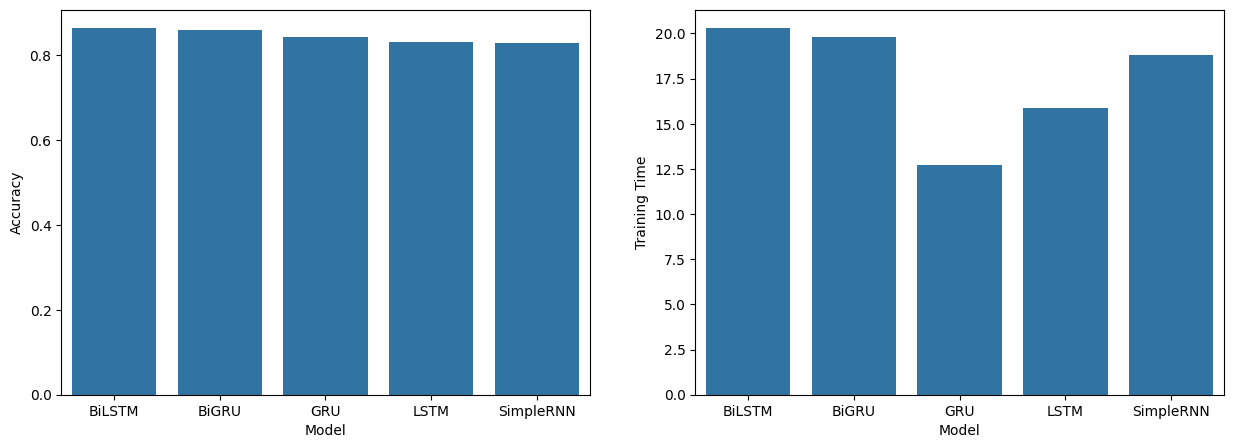

In [13]:
##visulising 1)accuracy and 2)traing time of 5 models

fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.barplot(x='Model',y='Accuracy',data=results,ax=axes[0])
sns.barplot(x='Model',y='Training Time',data=results,ax=axes[1])
plt.show()